### Newcast OCR EDA

## 1. Understanding how many frames have text across both newcasts

Telejornal_RTP_Dec_11                     with=2,854  without=   0  total=2,854
Telejornal_RTP_Dec_18                     with=1,260  without=   1  total=1,261
Telejornal_RTP_Dec_2                      with=2,884  without=   1  total=2,885
Telejornal_RTP_Jan_13                     with=3,078  without=   0  total=3,078
Telejornal_RTP_Jan_6                      with=2,984  without=   1  total=2,985
Telejornal_RTP_Nov_10                     with=2,546  without=   0  total=2,546
Telejornal_RTP_Nov_20                     with=2,677  without=   0  total=2,677
Telejornal_TVI_Dec_11                     with=4,134  without=   0  total=4,134
Telejornal_TVI_Dec_18                     with=4,082  without=   0  total=4,082
Telejornal_TVI_Dec_2                      with=5,364  without=   4  total=5,368
Telejornal_TVI_Jan_11                     with=3,944  without=   1  total=3,945
Telejornal_TVI_Jan_6                      with=3,754  without=   0  total=3,754
Telejornal_TVI_Nov_10                   

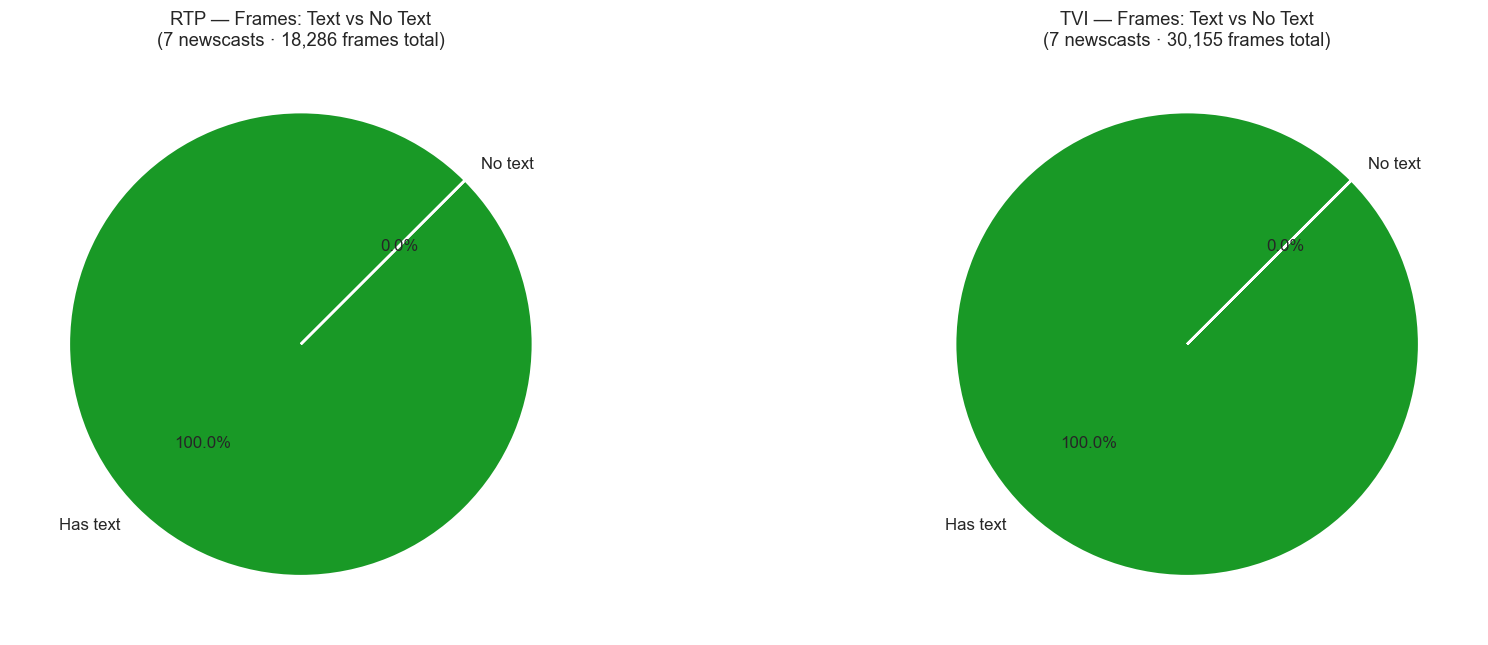

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import numpy as np
import re 

BASE = Path.cwd()
base_dir = Path(BASE)


pkl_files = sorted(base_dir.glob('*.pkl'))

total_with_text    = 0
total_without_text = 0
summary_rows       = []

channels = {'RTP': {'with': 0, 'without': 0, 'files': 0},
            'TVI': {'with': 0, 'without': 0, 'files': 0}}

for fpath in pkl_files:
    df = pd.read_pickle(fpath)
    df['n_detections'] = df['OCR'].apply(len)
    with_text    = (df['n_detections'] > 0).sum()
    without_text = (df['n_detections'] == 0).sum()
    total_with_text    += with_text
    total_without_text += without_text
    
    name = fpath.name.replace('_ocr.pkl', '')
    summary_rows.append({'file': name, 'with_text': with_text, 'without_text': without_text})
    print(f'{name:40s}  with={with_text:>5,}  without={without_text:>4,}  total={len(df):>5,}')

    for ch in channels:
        if ch in fpath.name.upper():
            channels[ch]['with']    += with_text
            channels[ch]['without'] += without_text
            channels[ch]['files']   += 1

total_frames = total_with_text + total_without_text

# ── Pie charts: combined + one per channel ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

charts = [
    ('RTP', channels['RTP']['with'], channels['RTP']['without'], channels['RTP']['files']),
    ('TVI', channels['TVI']['with'], channels['TVI']['without'], channels['TVI']['files']),
]

for ax, (title, w, wo, n_files) in zip(axes, charts):
    total = w + wo
    ax.pie(
        [w, wo],
        labels=['Has text', 'No text'],
        autopct='%1.1f%%',
        colors=['#199926', '#DD8452'],
        startangle=45,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    )
    ax.set_title(
        f'{title} — Frames: Text vs No Text\n'
        f'({n_files} newscasts · {total:,} frames total)',
        fontsize=12,
    )

plt.tight_layout()
plt.show()

## 2. Text Detection by bounding box screen position

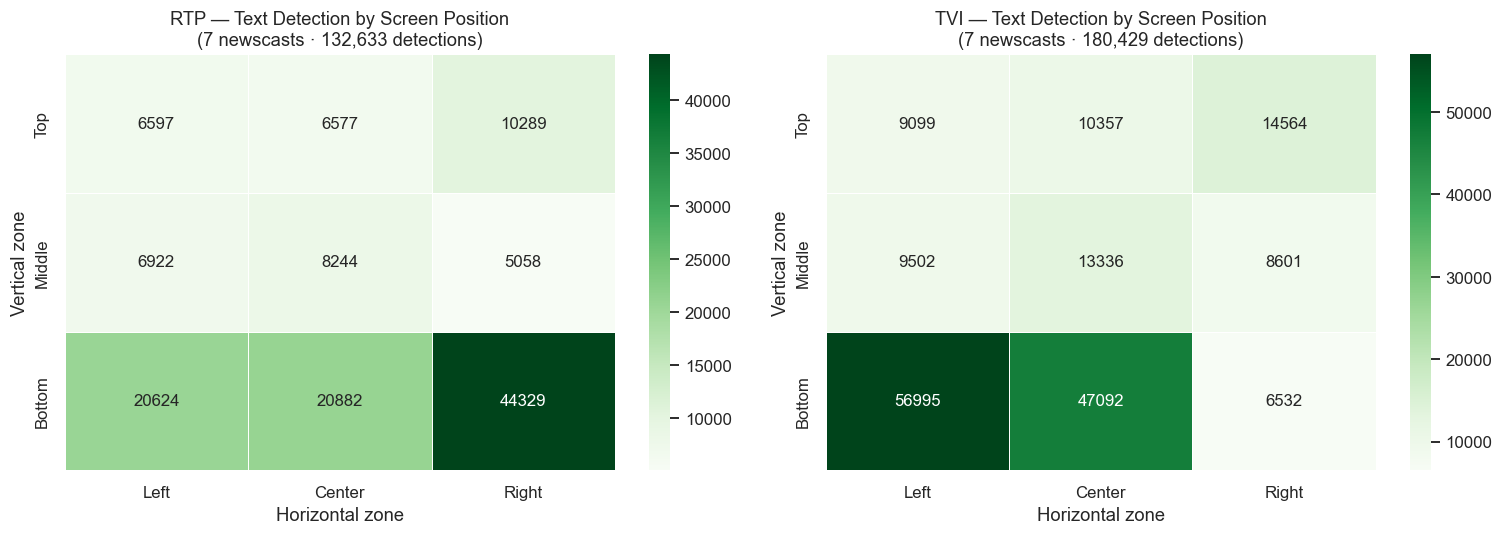

In [ ]:



def build_bbox_df(fpaths):
    records = []
    for fpath in fpaths:
        df = pd.read_pickle(fpath)
        for _, row in df.iterrows():
            for det in row['OCR']:
                bbox = det.get('bbox', [])
                if isinstance(bbox, list) and len(bbox) == 4:
                    x1, y1, x2, y2 = bbox
                    records.append({'cx': (x1 + x2) / 2, 'cy': (y1 + y2) / 2,
                                    'x2': x2, 'y2': y2})
    return pd.DataFrame(records)

channel_files = {
    'RTP': [f for f in pkl_files if 'RTP' in f.name.upper()],
    'TVI': [f for f in pkl_files if 'TVI' in f.name.upper()],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ch, fpaths) in zip(axes, channel_files.items()):
    if not fpaths:
        ax.set_title(f'{ch} — no files found')
        ax.axis('off')
        continue

    bbox_df = build_bbox_df(fpaths)

    W_EST = bbox_df['x2'].quantile(0.95)
    H_EST = bbox_df['y2'].quantile(0.95)

    bbox_df['col_zone'] = pd.cut(bbox_df['cx'] / W_EST, bins=[0, 1/3, 2/3, 1],
                                  labels=['Left', 'Center', 'Right'])
    bbox_df['row_zone'] = pd.cut(bbox_df['cy'] / H_EST, bins=[0, 1/3, 2/3, 1],
                                  labels=['Top', 'Middle', 'Bottom'])

    zone_counts = (bbox_df.groupby(['row_zone', 'col_zone'], observed=True)
                          .size().unstack(fill_value=0))

    sns.heatmap(zone_counts, annot=True, fmt='d', cmap='Greens', ax=ax, linewidths=0.5)
    ax.set_title(f'{ch} — Text Detection by Screen Position\n'
                 f'({len(fpaths)} newscasts · {len(bbox_df):,} detections)')
    ax.set_xlabel('Horizontal zone')
    ax.set_ylabel('Vertical zone')

plt.tight_layout()
plt.show()

## 3. Distribution of text lengths per newcast channel.

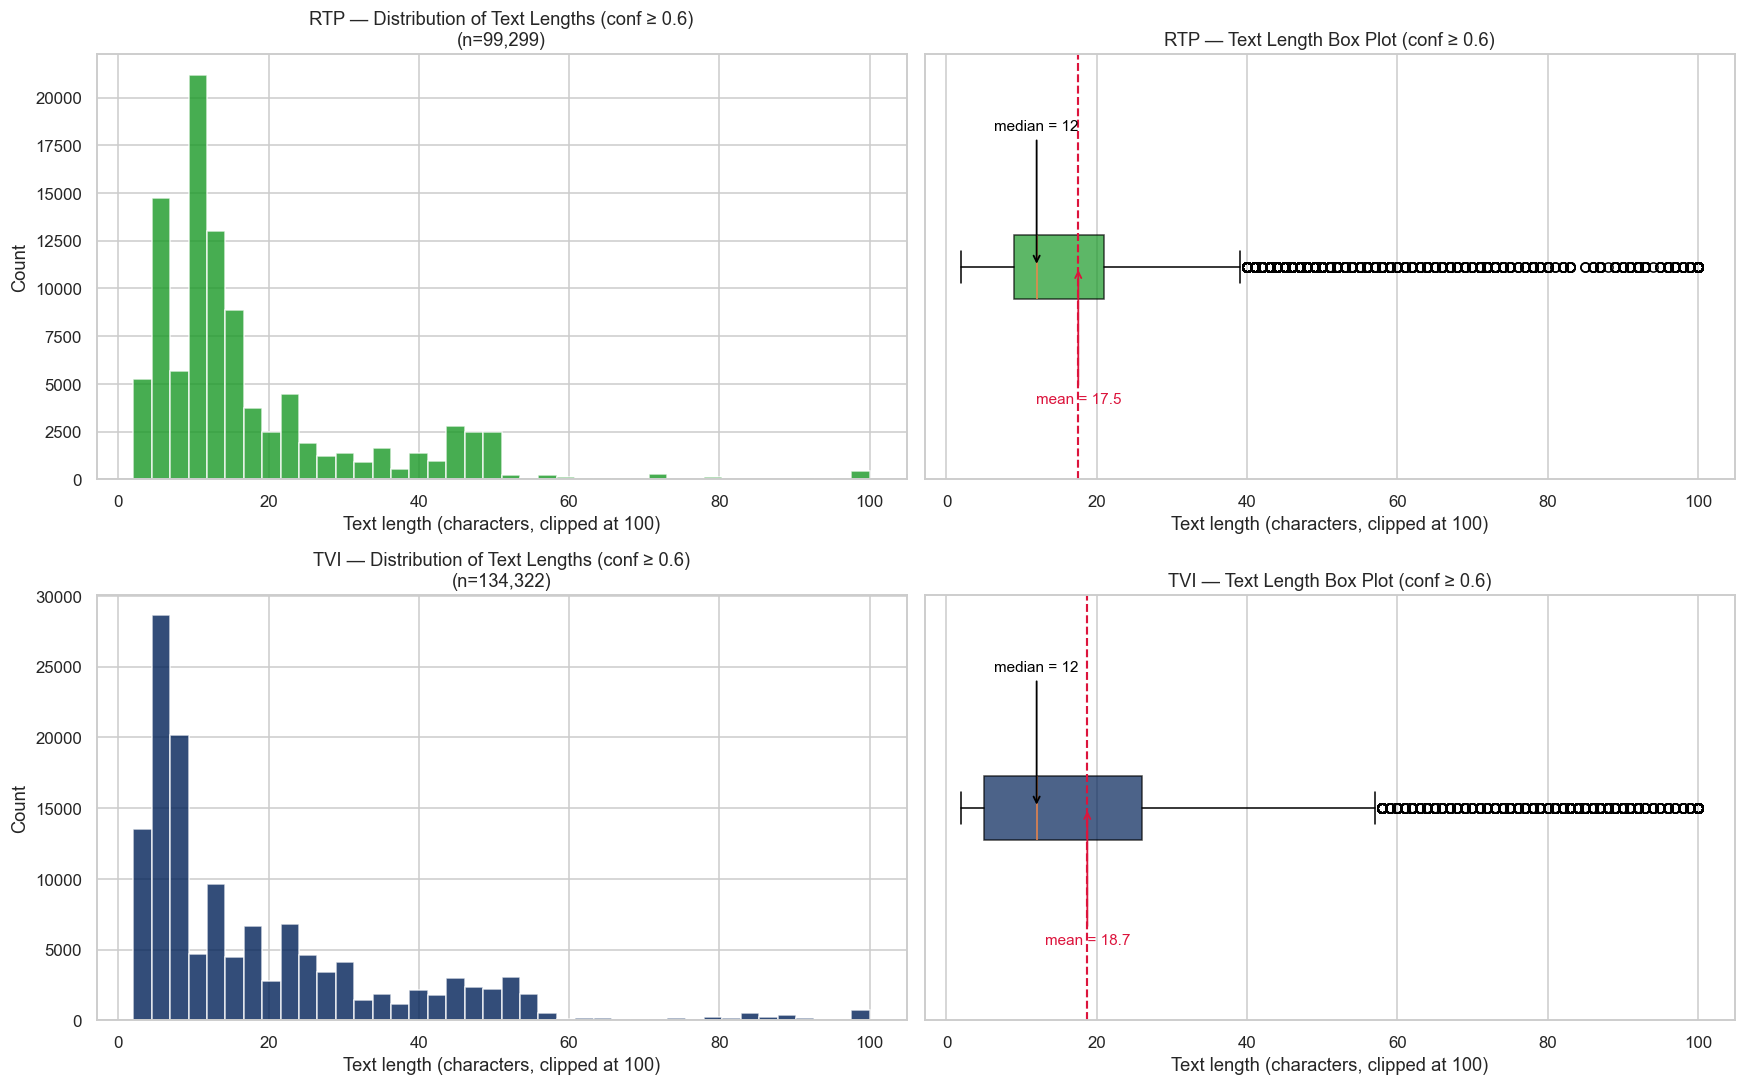

In [28]:

channel_files = {
    'RTP': [f for f in pkl_files if 'RTP' in f.name.upper()],
    'TVI': [f for f in pkl_files if 'TVI' in f.name.upper()],
}

def collect_text_lengths(fpaths):
    lengths = []
    for fpath in fpaths:
        df = pd.read_pickle(fpath)
        for _, row in df.iterrows():
            for det in row['OCR']:
                if det.get('conf', 0) < 0.6:
                    continue
                raw = re.sub(r'<[^>]+>', '', str(det.get('text', ''))).strip()
                if len(raw) > 1:
                    lengths.append(len(raw))
    return lengths

channel_colors = {'RTP': '#199926', 'TVI': '#002157'}
channel_lengths = {ch: collect_text_lengths(fps) for ch, fps in channel_files.items()}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row_idx, (ch, lengths) in enumerate(channel_lengths.items()):
    color = channel_colors[ch]
    clipped = [min(l, 100) for l in lengths]

    # ── Histogram ─────────────────────────────────────────────────────────
    ax_hist = axes[row_idx, 0]
    ax_hist.hist(clipped, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax_hist.set_xlabel('Text length (characters, clipped at 100)')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f'{ch} — Distribution of Text Lengths (conf ≥ 0.6)\n'
                      f'(n={len(lengths):,})')

    # ── Horizontal box plot ───────────────────────────────────────────────
    ax_box = axes[row_idx, 1]
    bp = ax_box.boxplot(clipped, vert=False, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)

    median_val = bp['medians'][0].get_xdata()[0]
    mean_val   = np.mean(clipped)

    # mean marker
    ax_box.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.4)

    # median annotation (above)
    ax_box.annotate(f'median = {median_val:.0f}',
                    xy=(median_val, 1), xytext=(median_val, 1.32),
                    ha='center', fontsize=10, color='black',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

    # mean annotation (below)
    ax_box.annotate(f'mean = {mean_val:.1f}',
                    xy=(mean_val, 1), xytext=(mean_val, 0.68),
                    ha='center', fontsize=10, color='crimson',
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

    ax_box.set_xlabel('Text length (characters, clipped at 100)')
    ax_box.set_yticks([])
    ax_box.set_title(f'{ch} — Text Length Box Plot (conf ≥ 0.6)')

plt.tight_layout()
plt.show()

## 4. Top 20 words detected by newcast channel.

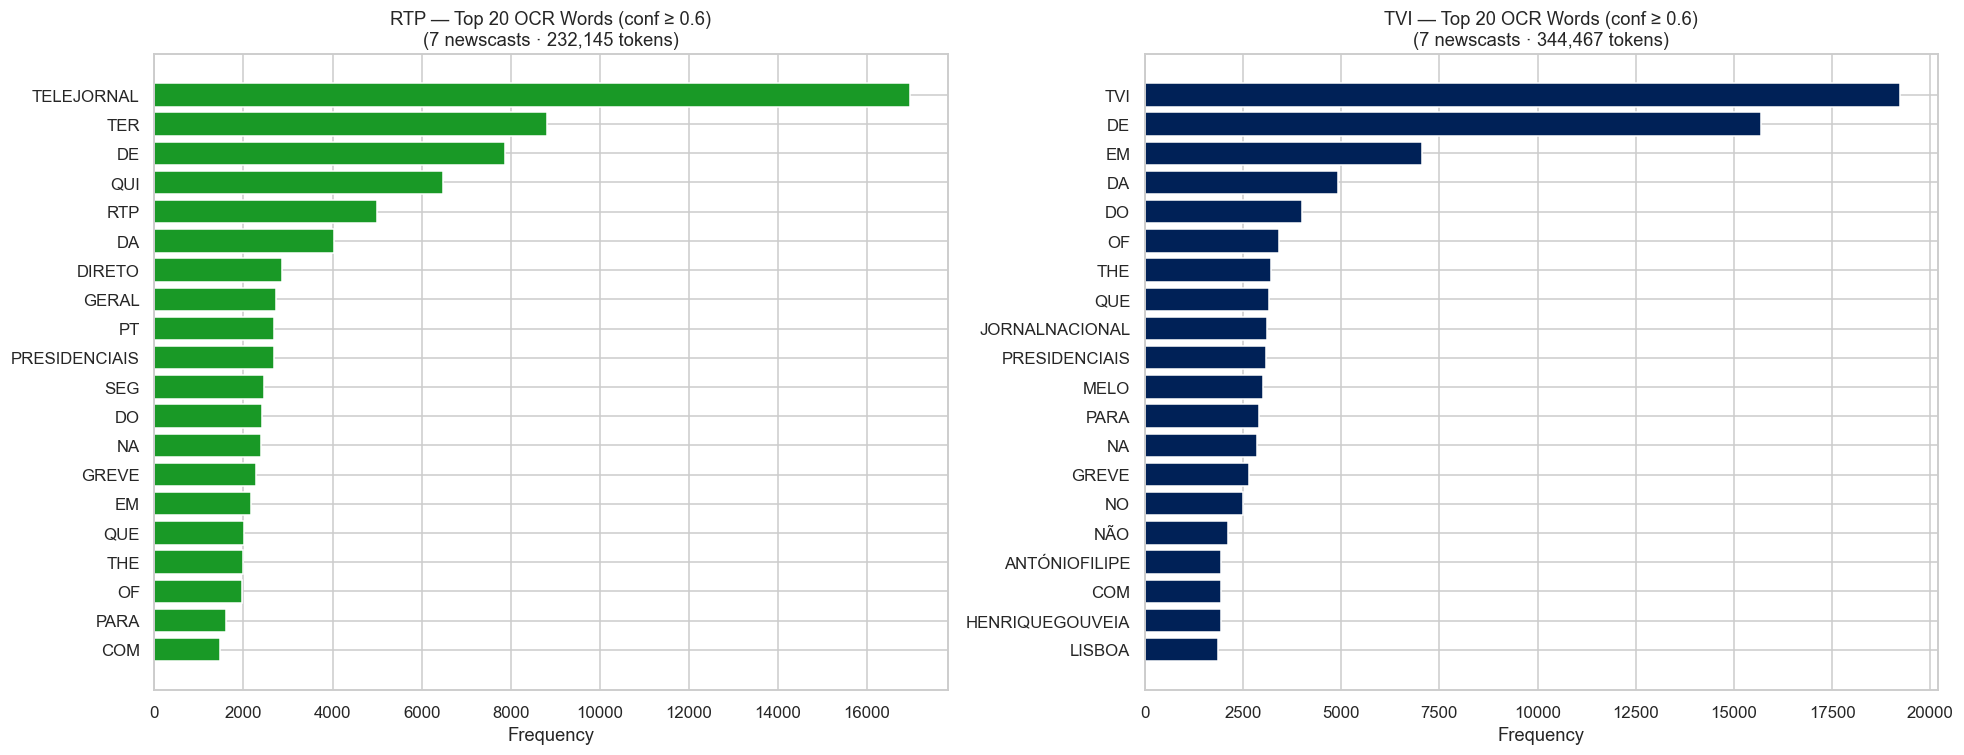

In [29]:
from collections import Counter


channel_files = {
    'RTP': [f for f in pkl_files if 'RTP' in f.name.upper()],
    'TVI': [f for f in pkl_files if 'TVI' in f.name.upper()],
}

def collect_word_freq(fpaths):
    words = []
    for fpath in fpaths:
        df = pd.read_pickle(fpath)
        for _, row in df.iterrows():
            for det in row['OCR']:
                if det.get('conf', 0) < 0.6:
                    continue
                raw = re.sub(r'<[^>]+>', '', str(det.get('text', ''))).strip()
                if len(raw) <= 1:
                    continue
                tokens = re.findall(r'[A-Za-zÀ-ÿ]{2,}', raw)
                words.extend([t.upper() for t in tokens])
    return Counter(words)

channel_colors = {'RTP': '#199926', 'TVI': '#002157'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (ch, fpaths) in zip(axes, channel_files.items()):
    freq = collect_word_freq(fpaths)
    top20 = freq.most_common(20)
    if not top20:
        ax.set_title(f'{ch} — no data')
        ax.axis('off')
        continue
    words_list, counts_list = zip(*top20)
    ax.barh(list(reversed(words_list)), list(reversed(counts_list)),
            color=channel_colors[ch])
    ax.set_xlabel('Frequency')
    ax.set_title(f'{ch} — Top 20 OCR Words (conf ≥ 0.6)\n'
                 f'({len(fpaths)} newscasts · {sum(freq.values()):,} tokens)')

plt.tight_layout()
plt.show()

## 5. Do we have frames that are not about news?

Since we have frames without the news chyron on the bottom, we could infer that those frames would be advertising of something not related to news.


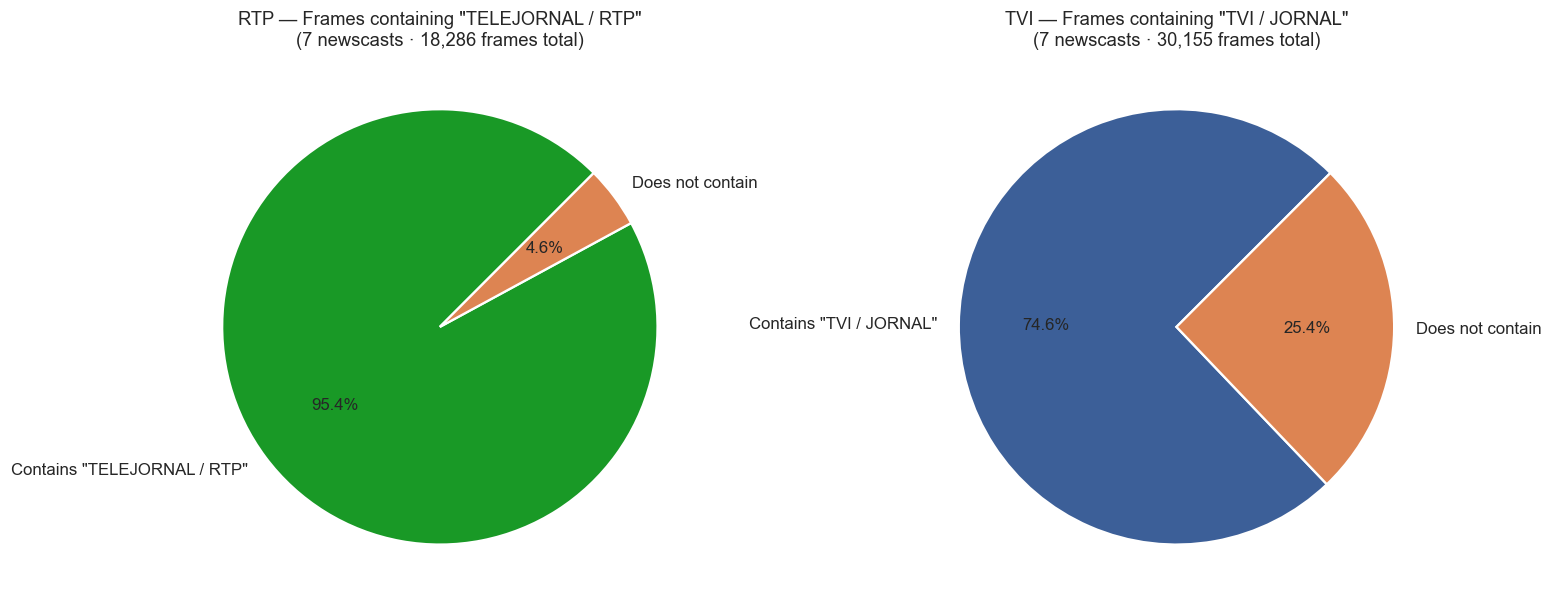

In [30]:

channel_config = {
    'RTP': {
        'files':    [f for f in pkl_files if 'RTP' in f.name.upper()],
        'keywords': ['TELEJORNAL', 'RTP'],
        'color':    '#199926',
    },
    'TVI': {
        'files':    [f for f in pkl_files if 'TVI' in f.name.upper()],
        'keywords': ['TVI','JORNAL'],
        'color':    "#3C5F98",
    },
}

def frame_keyword_counts(fpaths, keywords):
    with_kw = 0
    without_kw = 0
    for fpath in fpaths:
        df = pd.read_pickle(fpath)
        for _, row in df.iterrows():
            texts = [re.sub(r'<[^>]+>', '', str(det.get('text', ''))).upper()
                     for det in row['OCR']]
            found = any(kw in t for t in texts for kw in keywords)
            if found:
                with_kw += 1
            else:
                without_kw += 1
    return with_kw, without_kw

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (ch, cfg) in zip(axes, channel_config.items()):
    with_kw, without_kw = frame_keyword_counts(cfg['files'], cfg['keywords'])
    total = with_kw + without_kw
    kw_label = ' / '.join(cfg['keywords'])

    ax.pie(
        [with_kw, without_kw],
        labels=[f'Contains "{kw_label}"', 'Does not contain'],
        autopct='%1.1f%%',
        colors=[cfg['color'], '#DD8452'],
        startangle=45,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    )
    ax.set_title(
        f'{ch} — Frames containing "{kw_label}"\n'
        f'({len(cfg["files"])} newscasts · {total:,} frames total)',
        fontsize=12,
    )

plt.tight_layout()
plt.show()